In [1]:
import pandas as pd
import sqlite3
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [59]:
conn = sqlite3.connect("mydatabase.db")

In [62]:
query = """
SELECT 
    c.client_id,
    c.age,
    c.job,
    f.balance,
    f.housing,
    f.loan,
    ca.duration,
    ca.campaign,
    t.y
FROM client c
LEFT JOIN financial f ON c.client_id = f.client_id
LEFT JOIN campaign ca ON c.client_id = ca.client_id
LEFT JOIN target t ON c.client_id = t.client_id
"""

In [63]:
df = pd.read_sql_query(query, conn)
df

,client_id,age,job,balance,housing,loan,duration,campaign,y
0,0,18,student,1944,no,no,122,3,no
1,1,18,student,108,no,no,167,1,yes
2,2,18,student,608,no,no,267,1,yes
3,3,18,student,35,no,no,104,2,no
4,4,18,student,5,no,no,143,2,no
...,...,...,...,...,...,...,...,...,...
45206,45206,93,retired,775,no,no,860,2,yes
45207,45207,93,retired,775,no,no,476,2,yes
45208,45208,94,retired,1234,no,no,212,1,no
45209,45209,95,retired,2282,no,no,207,17,yes


In [64]:
pd.read_sql("SELECT COUNT(*) FROM client", conn)
pd.read_sql("SELECT COUNT(*) FROM financial", conn)
pd.read_sql("SELECT COUNT(*) FROM campaign", conn)
pd.read_sql("SELECT COUNT(*) FROM target", conn)

,COUNT(*)
0,45211


In [65]:
print(df.dtypes)

client_id     int64
age           int64
job          object
balance       int64
housing      object
loan         object
duration      int64
campaign      int64
y            object
dtype: object


In [66]:
df['balance'] = pd.to_numeric(df['balance'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df['campaign'] = pd.to_numeric(df['campaign'], errors='coerce')

In [67]:
df = df.fillna(0)

In [69]:
X = df[['age', 'balance', 'duration', 'campaign']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [70]:
features = ['age', 'balance', 'duration', 'campaign']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df

,client_id,age,job,balance,housing,loan,duration,campaign,cluster
0,0,18,student,1944,no,no,122,3,0
1,1,18,student,108,no,no,167,1,0
2,2,18,student,608,no,no,267,1,0
3,3,18,student,35,no,no,104,2,0
4,4,18,student,5,no,no,143,2,0
...,...,...,...,...,...,...,...,...,...
45206,45206,93,retired,775,no,no,860,2,1
45207,45207,93,retired,775,no,no,476,2,1
45208,45208,94,retired,1234,no,no,212,1,1
45209,45209,95,retired,2282,no,no,207,17,2


In [71]:
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

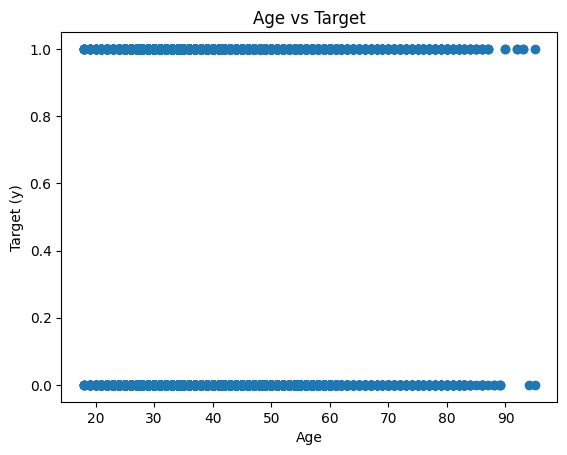

In [72]:
plt.figure()

plt.scatter(df['age'], df['y'])

plt.xlabel("Age")
plt.ylabel("Target (y)")
plt.title("Age vs Target")

plt.show()

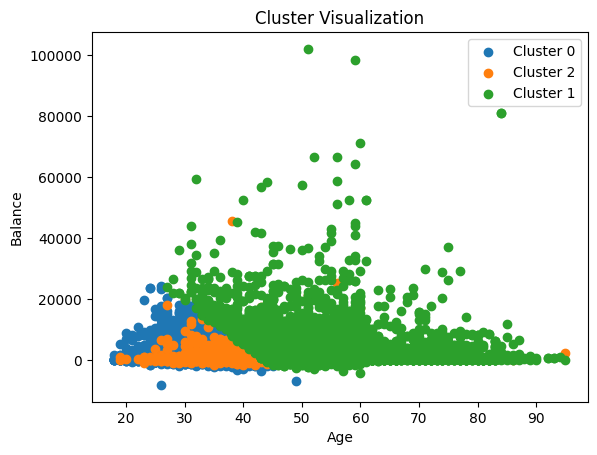

In [49]:
plt.figure()

for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['age'], subset['balance'], label=f'Cluster {cluster}')

plt.xlabel("Age")
plt.ylabel("Balance")
plt.title("Cluster Visualization")
plt.legend()

plt.show()

In [51]:
df.groupby('cluster')[['age','balance','duration','campaign']].mean()

,age,balance,duration,campaign
cluster,,,,
0,34.077428,958.311343,270.207439,2.241925
1,52.192354,2049.297423,249.267723,2.388761
2,40.278621,1091.071846,154.341706,14.606893


In [52]:
def label_cluster(row):
    if row['cluster'] == 0:
        return "Low Value Clients"
    elif row['cluster'] == 1:
        return "High Value Clients"
    else:
        return "Average Clients"

df['cluster_label'] = df.apply(label_cluster, axis=1)

In [53]:
df[['client_id','cluster','cluster_label']]

,client_id,cluster,cluster_label
0,0,0,Low Value Clients
1,1,0,Low Value Clients
2,2,0,Low Value Clients
3,3,0,Low Value Clients
4,4,0,Low Value Clients
...,...,...,...
45206,45206,1,High Value Clients
45207,45207,1,High Value Clients
45208,45208,1,High Value Clients
45209,45209,2,Average Clients


In [54]:
cluster_summary = df.groupby('cluster')[['balance','duration']].mean()

labels = {}

for i in cluster_summary.index:
    if cluster_summary.loc[i, 'balance'] > 3000:
        labels[i] = "High Value Clients"
    elif cluster_summary.loc[i, 'duration'] > 100:
        labels[i] = "Engaged Clients"
    else:
        labels[i] = "Low Value Clients"

df['cluster_label'] = df['cluster'].map(labels)